# DSCI 303 - Homework 07

### Sean Graham

**Due: Sunday, June 21, 2020, 11:59 pm**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

## Part 1: NYC Restaurants Dataset

In [2]:
nyc = pd.read_csv('nyc.txt', sep='\t')
nyc.head(10)

,Price,Food,Decor,Service,Wait,East
0,43,22,18,20,36,0
1,32,20,19,19,22,0
2,34,21,13,18,20,0
3,41,20,20,17,25,0
4,54,24,19,21,32,0
5,52,22,22,21,15,0
6,34,22,16,21,25,0
7,34,20,18,21,21,1
8,39,22,19,22,23,1
9,44,21,17,19,27,1


In [3]:
X1 = nyc.iloc[:,1:].values
y1 = nyc.iloc[:,0].values

X_train_1, X_test_1, y_train_1, y_test_1 =\
    train_test_split(X1, y1, test_size = 0.2, random_state=1)

print('Training Features Shape: ' + str(X_train_1.shape))
print('Test Features Shape:     ' + str(X_test_1.shape))

Training Features Shape: (134, 5)
Test Features Shape:     (34, 5)


In [4]:
nyc_mod = LinearRegression()
nyc_mod.fit(X_train_1, y_train_1)

print('Intercept:    ' + str(nyc_mod.intercept_))
print('Coefficients: ' + str(nyc_mod.coef_))

Intercept:    -23.75543532248892
Coefficients: [ 1.55693926  2.00700907 -0.25440527  0.09203064  2.63235537]


In [5]:
train_r2 = nyc_mod.score(X_train_1, y_train_1)
test_r2 = nyc_mod.score(X_test_1, y_test_1)

print('Training r-Squared:', round(train_r2,4))
print('Testing r-Squared: ', round(test_r2,4))

Training r-Squared: 0.6306
Testing r-Squared:  0.6245


In [6]:
test_pred_1 = nyc_mod.predict(X_test_1)

print('Observed Prices: ', y_test_1[:10])
print('Estimated Prices:', np.round(test_pred_1[:10,],2))

Observed Prices:  [33 45 54 38 22 47 38 51 46 47]
Estimated Prices: [39.2  38.09 49.35 39.26 19.72 47.4  36.85 50.07 48.26 43.01]


In [7]:
data = [[22, 12, 20, 15, 0],
        [18, 19, 22, 34, 1],
        [25, 22, 18, 36, 0]]
nyc_new = pd.DataFrame(data = data,
                       columns = ['Food', 'Decor', 'Service', 'Wait', 'East'])

new_pred_1 = nyc_mod.predict(nyc_new)
print('Estimated Prices:', np.round(new_pred_1,2))

Estimated Prices: [30.87 42.57 58.06]


## Part 2: Diamonds Dataset

In [8]:
diamonds = pd.read_csv('diamonds.txt', sep='\t')
diamonds.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [9]:
diamonds.loc[:,'ln_carat'] = np.log(diamonds.loc[:,'carat'])
diamonds.loc[:,'ln_price'] = np.log(diamonds.loc[:,'price'])
diamonds.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z,ln_carat,ln_price
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,-1.469676,5.786897
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,-1.560648,5.786897
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,-1.469676,5.789960
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,-1.237874,5.811141
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,-1.171183,5.814131


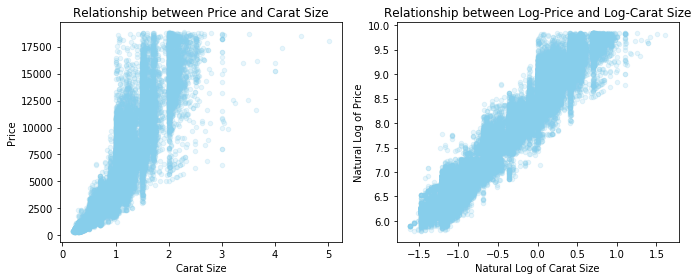

In [10]:
plt.figure(figsize=[10,4])

plt.subplot(1,2,1)
plt.scatter(diamonds.loc[:,'carat'], diamonds.loc[:, 'price'], s = 20, alpha = 0.2, color = 'skyblue')
plt.xlabel('Carat Size')
plt.ylabel('Price')
plt.title('Relationship between Price and Carat Size')

plt.subplot(1,2,2)
plt.scatter(diamonds.loc[:,'ln_carat'], diamonds.loc[:, 'ln_price'], s = 20, alpha = 0.2, color = 'skyblue')
plt.xlabel('Natural Log of Carat Size')
plt.ylabel('Natural Log of Price')
plt.title('Relationship between Log-Price and Log-Carat Size')

plt.tight_layout()
plt.show()

In [11]:
X2 = diamonds.iloc[:,-2].values
y2 = diamonds.iloc[:,-1].values

X_train_2, X_test_2, y_train_2, y_test_2 =\
    train_test_split(X2, y2, test_size = 0.1, random_state=1)

print('Training Features Shape: ' + str(X_train_2.shape))
print('Test Features Shape:     ' + str(X_test_2.shape))

Training Features Shape: (48546,)
Test Features Shape:     (5394,)


In [12]:
X_train_2 = X_train_2.reshape(48546,1)
X_test_2 = X_test_2.reshape(5394,1)

dia_mod = LinearRegression()
dia_mod.fit(X_train_2, y_train_2)

print('Intercept:    ' + str(dia_mod.intercept_))
print('Coefficients: ' + str(dia_mod.coef_))

Intercept:    8.448298621179152
Coefficients: [1.67493107]


In [13]:
train_r2 = dia_mod.score(X_train_2, y_train_2)
test_r2 = dia_mod.score(X_test_2, y_test_2)

print('Training r-Squared:', round(train_r2, 4))
print('Testing r-Squared: ', round(test_r2, 4))

Training r-Squared: 0.933
Testing r-Squared:  0.9328


In [14]:
test_pred_2 = dia_mod.predict(X_test_2)

print('Observed Prices: ', np.exp(y_test_2[:10]))
print('Estimated Prices:', np.round(np.exp(test_pred_2[:10,]),0))

Observed Prices:  [ 564. 5914. 2562.  537. 5964.  984. 5247.  611. 9645. 1162.]
Estimated Prices: [ 729. 6334. 2096.  766. 6334. 1612. 5309. 1048. 9204.  804.]


In [15]:
diamonds_new = np.log([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])

diamonds_new = diamonds_new.reshape(6,1)

new_pred_2 = dia_mod.predict(diamonds_new)
print('Estimated Prices:', np.round(np.exp(new_pred_2),0))

Estimated Prices: [ 1462.  4667.  9204. 14902. 21656. 29390.]


## Part 3: Heart Disease Dataset

In [16]:
hd = pd.read_csv('heart_disease.txt', sep='\t')
hd.head(5)

,age,sex,chest_pain_type,resting_bp,serum_chol,fasting_blood_sugar,electrocardio,max_heart_rate,exercise_induced_angina,oldpeak,slope,major_vessels,thal,heart_disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


In [17]:
X3 = hd.iloc[:,:-1].values
y3 = hd.iloc[:,-1].values

X_train_3, X_test_3, y_train_3, y_test_3 =\
    train_test_split(X3, y3, test_size = 0.2, random_state=1, stratify=y3)

print('Training Features Shape: ' + str(X_train_3.shape))
print('Test Features Shape:     ' + str(X_test_3.shape))

Training Features Shape: (216, 13)
Test Features Shape:     (54, 13)


In [18]:
hd_mod = LogisticRegression(solver='lbfgs', penalty='none', max_iter = 1000)
hd_mod.fit(X_train_3, y_train_3)

print('Intercept:    ' + str(hd_mod.intercept_))
print('Coefficients: \n' + str(hd_mod.coef_))

Intercept:    [-9.82675877]
Coefficients: 
[[-0.03360662  1.80267898  0.75279697  0.02509655  0.01435935 -0.70520438
   0.32552051 -0.0195919   0.72684946  0.36703604  0.28327132  1.07507207
   0.38394135]]


In [19]:
train_acc = hd_mod.score(X_train_3, y_train_3)
test_acc = hd_mod.score(X_test_3, y_test_3)

print('Training Accuracy:', round(train_acc, 4))
print('Testing Accuracy: ', round(test_acc, 4))

Training Accuracy: 0.8472
Testing Accuracy:  0.8148


In [20]:
test_pred_3 = hd_mod.predict(X_test_3)

print('Observed Labels: ', y_test_3[:20])
print('Estimated Labels:', test_pred_3[:20,])

Observed Labels:  [2 2 2 1 1 2 1 1 2 1 2 1 1 1 2 1 1 1 2 1]
Estimated Labels: [2 2 2 1 1 2 1 1 2 1 2 1 1 1 2 1 1 1 2 1]


In [21]:
hd_df_data = hd_mod.predict_proba(X_test_3[:10,])
pd.DataFrame(data = hd_df_data, columns = ['1','2'])

,1,2
0,0.011766,0.988234
1,0.043240,0.956760
2,0.040409,0.959591
3,0.847858,0.152142
4,0.873737,0.126263
5,0.051925,0.948075
6,0.920485,0.079515
7,0.945005,0.054995
8,0.010020,0.989980
9,0.996700,0.003300


## Part 4: Gapminder Dataset

In [22]:
gm = pd.read_csv('gapminder_data.txt', sep='\t')

sel = gm.loc[:,'year'] == 2018
gm18 = gm.loc[sel,:]

gm18.head(10)

,country,year,continent,population,life_exp,gdp_per_cap,gini
40112,Afghanistan,2018,asia,36400000,58.7,1870,36.8
40113,Albania,2018,europe,2930000,78.0,12400,29.0
40114,Algeria,2018,africa,42000000,77.9,13700,27.6
40115,Angola,2018,africa,30800000,65.2,5850,42.6
40116,Antigua and Barbuda,2018,americas,103000,77.6,21000,40.0
40117,Argentina,2018,americas,44700000,77.0,18900,42.4
40118,Armenia,2018,europe,2930000,76.0,8660,32.6
40119,Australia,2018,asia,24800000,82.9,45800,32.3
40120,Austria,2018,europe,8750000,81.8,44600,30.5
40121,Azerbaijan,2018,europe,9920000,72.3,16600,32.4


In [23]:
X4 = gm18.iloc[:,-3:].values
y4 = gm18.iloc[:,2].values

X_train_4, X_test_4, y_train_4, y_test_4 =\
    train_test_split(X4, y4, test_size = 0.3, random_state=1, stratify=y4)

print('Training Features Shape: ' + str(X_train_4.shape))
print('Test Features Shape:     ' + str(X_test_4.shape))

Training Features Shape: (128, 3)
Test Features Shape:     (56, 3)


In [24]:
gm_mod = LogisticRegression(solver='lbfgs', penalty='none', multi_class='multinomial', max_iter = 200)
gm_mod.fit(X_train_4, y_train_4)

print('Intercept:    ' + str(gm_mod.intercept_))
print('Coefficients: \n' + str(gm_mod.coef_))

Intercept:    [ 0.00205072 -0.00472741  0.00331948 -0.0006428 ]
Coefficients: 
[[-8.83353894e-02 -1.02860879e-04  2.00995117e-01]
 [-8.62639892e-02  3.30477858e-05  1.59844962e-01]
 [ 1.94014805e-02  2.94681842e-05 -2.34220692e-02]
 [ 1.55197898e-01  4.03449086e-05 -3.37418010e-01]]


In [25]:
train_acc = gm_mod.score(X_train_4, y_train_4)
test_acc = gm_mod.score(X_test_4, y_test_4)

print('Training Accuracy:', round(train_acc, 4))
print('Testing Accuracy: ', round(test_acc, 4))

Training Accuracy: 0.625
Testing Accuracy:  0.5893


In [26]:
test_pred_4 = gm_mod.predict(X_test_4)

print('Observed Labels: ', y_test_4[:8])
print('Estimated Labels:', test_pred_4[:8,])

Observed Labels:  ['americas' 'asia' 'asia' 'asia' 'africa' 'europe' 'asia' 'europe']
Estimated Labels: ['asia' 'europe' 'africa' 'asia' 'europe' 'europe' 'africa' 'europe']


In [27]:
gm_df_data = gm_mod.predict_proba(X_test_4[:10,])
pd.DataFrame(data = gm_df_data, columns = ['africa','americas','asia','europe'])

,africa,americas,asia,europe
0,0.066439,0.259389,0.578341,0.095830
1,0.001111,0.043586,0.358370,0.596933
2,0.662840,0.210855,0.122837,0.003468
3,0.227101,0.261975,0.456486,0.054438
4,0.002035,0.004909,0.112530,0.880527
5,0.001851,0.023835,0.252549,0.721765
6,0.630329,0.219004,0.146747,0.003920
7,0.000027,0.000735,0.033230,0.966009
8,0.001242,0.010825,0.163607,0.824326
9,0.178341,0.117880,0.492398,0.211381


In [28]:
data = [[75, 5000, 30],
        [75, 5000, 40],
        [75, 5000, 50],
        [75, 20000, 30],
        [75, 20000, 40],
        [75, 20000, 50]]
gm_new = pd.DataFrame(data = data,
                       columns = ['life_exp', 'gdp_per_cap', 'gini',])

gm_new_df_data = gm_mod.predict_proba(gm_new)
pd.DataFrame(data = np.round(gm_new_df_data, 3), columns = ['africa','americas','asia','europe'])

,africa,americas,asia,europe
0,0.038,0.026,0.287,0.649
1,0.433,0.191,0.343,0.034
2,0.726,0.212,0.061,0.000
3,0.005,0.025,0.265,0.705
4,0.092,0.313,0.533,0.061
5,0.259,0.582,0.158,0.001


According to our model:  
    • Country 0 is most likely in europe.  
    • Country 1 is most likely in africa.  
    • Country 2 is most likely in africa.  
    • Country 3 is most likely in europe.  
    • Country 4 is most likely in asia.  
    • Country 5 is most likely in americas.  